In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

In [2]:
file1 = '/Users/chenxisun/Downloads/MGB_all/Dataset_statistic/I0001_eeg_metadata_2024-10-01.csv'
file2 = '/Users/chenxisun/Downloads/BIDMC_all/I0002_eeg_metadata_20241110.csv'
file3 ='/Users/chenxisun/Downloads/BCH_all/I0003_eeg_metadata_20241112.csv'


df1_all = pd.read_csv(file1)
df2_all = pd.read_csv(file2)
df3_all = pd.read_csv(file3)

file1 = '/Users/chenxisun/Downloads/MGB_all/Dataset_statistic/MGB_Neurology_Reports_20thNovember.csv'
file2 = '/Users/chenxisun/Downloads/BIDMC_all/I0002-BIDMC/data_Unstructured/BIDMC_EEG_Reports/eeg_reports_bidmc.csv'
file3 = '/Users/chenxisun/Downloads/BCH_all/I0003-BCH/data_Unstructured/BCH_Notes_and_Reports_2024_11_15/EEG_Reports/I0003_eeg_reports_metadata_11202024.csv'

df1_report = pd.read_csv(file1)
df2_report = pd.read_csv(file2)
df3_report = pd.read_csv(file3)

file1_1 = '/Users/chenxisun/Desktop/heedb/MGH_EEG_with_reports.csv'
file1_2 = '/Users/chenxisun/Desktop/heedb/BWH_EEG_with_reports.csv'
file1 = '/Users/chenxisun/Desktop/heedb/MGB_EEG_with_reports.csv'
file2 = '/Users/chenxisun/Desktop/heedb/BIDMC_EEG_with_reports.csv'
file3 = '/Users/chenxisun/Desktop/heedb/BCH_EEG_with_reports.csv'

df11_match = pd.read_csv(file1_1)
df12_match = pd.read_csv(file1_2)

df1_match = pd.read_csv(file1)
df2_match = pd.read_csv(file2)
df3_match = pd.read_csv(file3)

In [98]:
df1_all=df1_all[['SiteID','BDSPPatientID','AgeAtVisit','SexDSC']]
df1_all['VisitCount'] = df1_all.groupby(['SiteID', 'BDSPPatientID']).transform('count')['AgeAtVisit']
df1_all['AgeAtVisitAvg'] = df1_all.groupby(['SiteID', 'BDSPPatientID'])['AgeAtVisit'].transform('mean')
df1_all = df1_all.drop_duplicates(subset=['SiteID', 'BDSPPatientID']).reset_index(drop=True)
df1_all=df1_all[['SiteID','BDSPPatientID','SexDSC','VisitCount','AgeAtVisitAvg']]
df1_all.loc[df1_all['SexDSC'] == 'Female', 'SexDSC'] = 'F'
df1_all.loc[df1_all['SexDSC'] == 'Male', 'SexDSC'] = 'M'

In [99]:
df2_all['SiteID']='I0002'
df2_all=df2_all[['SiteID','BDSPPatientID','AgeAtVisit','SexDSC']]
df2_all['VisitCount'] = df2_all.groupby(['SiteID', 'BDSPPatientID']).transform('count')['AgeAtVisit']
df2_all['AgeAtVisitAvg'] = df2_all.groupby(['SiteID', 'BDSPPatientID'])['AgeAtVisit'].transform('mean')
df2_all = df2_all.drop_duplicates(subset=['SiteID', 'BDSPPatientID']).reset_index(drop=True)
df2_all=df2_all[['SiteID','BDSPPatientID','SexDSC','VisitCount','AgeAtVisitAvg']]


df3_all['SiteID']='I0003'
df3_all=df3_all[['SiteID','BDSPPatientID','AgeAtVisit','SexDSC']]
df3_all['VisitCount'] = df3_all.groupby(['SiteID', 'BDSPPatientID']).transform('count')['AgeAtVisit']
df3_all['AgeAtVisitAvg'] = df3_all.groupby(['SiteID', 'BDSPPatientID'])['AgeAtVisit'].transform('mean')
df3_all = df3_all.drop_duplicates(subset=['SiteID', 'BDSPPatientID']).reset_index(drop=True)
df3_all=df3_all[['SiteID','BDSPPatientID','SexDSC','VisitCount','AgeAtVisitAvg']]

In [100]:
df_all = pd.concat([df1_all, df2_all, df3_all], ignore_index=True)
df_all = df_all.dropna(subset=['BDSPPatientID'])

In [101]:
custom_order = ['S0001', 'S0002', 'I0002', 'I0003']

# 将 SiteID 列转换为 Categorical 类型，并指定排序顺序
df_all['SiteID'] = pd.Categorical(df_all['SiteID'], categories=custom_order, ordered=True)

# 按照 SiteID 和 BDSPPatientID 排序
df_all = df_all.sort_values(by=['SiteID', 'BDSPPatientID']).reset_index(drop=True)


In [102]:
df_all

,SiteID,BDSPPatientID,SexDSC,VisitCount,AgeAtVisitAvg
0,S0001,111189188.0,F,6.0,23.0
1,S0001,111189302.0,F,3.0,78.0
2,S0001,111189591.0,F,1.0,35.0
3,S0001,111189719.0,M,2.0,52.0
4,S0001,111189925.0,F,1.0,40.0
...,...,...,...,...,...
109172,I0003,175945481.0,M,1.0,0.0
109173,I0003,175945484.0,F,2.0,0.0
109174,I0003,175945485.0,M,3.0,0.0
109175,I0003,175945486.0,M,5.0,0.0


In [103]:
df_all['HasEEG']='Y'
df_all['HasReports']='N'
df_all['MatchedEEGReports']='N'

In [104]:
df_all['HasReports']='N'

report_patients1=set(df1_report['BDSPPatientID'])
report_patients2=set(df2_report['BDSPPatientID'])
report_patients3=set(df3_report['BDSPPatientID'])

df_all.loc[df_all['BDSPPatientID'].isin(report_patients1), 'HasReports'] = 'Y'
df_all.loc[df_all['BDSPPatientID'].isin(report_patients2), 'HasReports'] = 'Y'
df_all.loc[df_all['BDSPPatientID'].isin(report_patients3), 'HasReports'] = 'Y'

In [105]:
df_all['MatchedEEGReports']='N'

match_patients11=set(df11_match['BDSPPatientID'])
match_patients12=set(df12_match['BDSPPatientID'])
match_patients2=set(df2_match['BDSPPatientID'])
match_patients3=set(df3_match['BDSPPatientID'])

df_all['BDSPPatientID'] = pd.to_numeric(df_all['BDSPPatientID'], errors='coerce')
df_all['BDSPPatientID'] = df_all['BDSPPatientID'].astype(float).astype(int)

df_all.loc[(df_all['BDSPPatientID'].isin(match_patients11)) & (df_all['SiteID']=='S0001'), 'MatchedEEGReports'] = 'Y'
df_all.loc[(df_all['BDSPPatientID'].isin(match_patients12)) & (df_all['SiteID']=='S0002'), 'MatchedEEGReports'] = 'Y'

df_all.loc[df_all['BDSPPatientID'].isin(match_patients2), 'MatchedEEGReports'] = 'Y'
df_all.loc[df_all['BDSPPatientID'].isin(match_patients3), 'MatchedEEGReports'] = 'Y'

df_all['BDSPPatientID']=df_all['BDSPPatientID'].astype(str)

In [106]:
df_all[df_all['MatchedEEGReports']=='Y']

,SiteID,BDSPPatientID,SexDSC,VisitCount,AgeAtVisitAvg,HasEEG,HasReports,MatchedEEGReports
0,S0001,111189188,F,6.0,23.0,Y,Y,Y
1,S0001,111189302,F,3.0,78.0,Y,Y,Y
2,S0001,111189591,F,1.0,35.0,Y,Y,Y
3,S0001,111189719,M,2.0,52.0,Y,Y,Y
4,S0001,111189925,F,1.0,40.0,Y,Y,Y
...,...,...,...,...,...,...,...,...
109172,I0003,175945481,M,1.0,0.0,Y,Y,Y
109173,I0003,175945484,F,2.0,0.0,Y,Y,Y
109174,I0003,175945485,M,3.0,0.0,Y,Y,Y
109175,I0003,175945486,M,5.0,0.0,Y,Y,Y


In [107]:
df_all.to_csv('/Users/chenxisun/Desktop/heedb/heedb_patients.csv', index=False)

In [124]:
#df=df_all[(df_all['SiteID']=='S0002') & (df_all['MatchedEEGReports']=='Y')]
df=df_all[df_all['MatchedEEGReports']=='Y']
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, float('inf')]
labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90', '90+']

df['AgeAtVisitAvg'] = df['AgeAtVisitAvg'].apply(lambda x: [float(age) for age in x.split(',')] if isinstance(x, str) else [x])

df['AgeAtVisitAvg'] = df['AgeAtVisitAvg'].apply(lambda x: np.mean(x) if isinstance(x, list) else x)

df['AgeGroup'] = pd.cut(df['AgeAtVisitAvg'], bins=bins, labels=labels, right=False)

age_group_counts = df['AgeGroup'].value_counts().sort_index()

print(age_group_counts)

AgeGroup
0-10     13796
10-20     8125
20-30     5444
30-40     4647
40-50     4797
50-60     7313
60-70     9456
70-80     8314
80-90     4619
90+        987
Name: count, dtype: int64


/var/folders/zy/xyng2q6d26l8w7cy180frh2r0000gn/T/ipykernel_82683/2682115466.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AgeAtVisitAvg'] = df['AgeAtVisitAvg'].apply(lambda x: [float(age) for age in x.split(',')] if isinstance(x, str) else [x])
/var/folders/zy/xyng2q6d26l8w7cy180frh2r0000gn/T/ipykernel_82683/2682115466.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AgeAtVisitAvg'] = df['AgeAtVisitAvg'].apply(lambda x: np.mean(x) if isinstance(x, list) else x)
/var/folders/zy/xyng2q6d26l8

In [141]:
df=df_all[(df_all['MatchedEEGReports']=='Y')]
df[df['SexDSC']=='M']['SexDSC'].count()

35205

In [3]:
file1 = '/Users/chenxisun/Desktop/heedb/MGB_EEG_with_reports3.csv'
file2 = '/Users/chenxisun/Desktop/heedb/BIDMC_EEG_with_reports3.csv'
file3 = '/Users/chenxisun/Desktop/heedb/BCH_EEG_with_reports3.csv'

df1_finding = pd.read_csv(file1)
df2_finding = pd.read_csv(file2)
df3_finding = pd.read_csv(file3)

df1_finding['BDSPPatientID']=df1_finding['BDSPPatientID'].astype(str)
df1_finding['StartTime(EEG)'] = pd.to_datetime(df1_finding['StartTime(EEG)'], errors='coerce')

/var/folders/zy/xyng2q6d26l8w7cy180frh2r0000gn/T/ipykernel_11187/4253870454.py:5: DtypeWarning: Columns (38,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df1_finding = pd.read_csv(file1)
/var/folders/zy/xyng2q6d26l8w7cy180frh2r0000gn/T/ipykernel_11187/4253870454.py:7: DtypeWarning: Columns (25,35,36,38,40,41,50) have mixed types. Specify dtype option on import or set low_memory=False.
  df3_finding = pd.read_csv(file3)


In [4]:
df1_finding.columns

Index(['SiteID', 'BDSPPatientID', 'SessionID', 'AgeAtVisit', 'SexDSC',
       'ServiceName(EEG)', 'CreationTime(EEG)', 'StartTime(EEG)',
       'EndTime(EEG)', 'ProcedureDSC(Reports)', 'EncounterDTS(Reports)',
       'BeginDTS(Reports)', 'ExamEndDTS(Reports)', 'DeidentifiedName(Reports)',
       'available', 'normal', 'abnormal', 'awake', 'n1', 'n2', 'bets',
       'wicket', 'spindles', 'vertex wave', 'posts', 'breach', 'spikes',
       'seizure', 'lpd', 'gpd', 'lrda', 'grda', 'bs', 'foc slowing',
       'gen slowing', 'pdr', 'dravet', 'eses', 'fold', 'jae', 'jeavons', 'jme',
       'k_complexes', 'bects', 'bipd', 'cjd', 'diffuse Beta', 'low voltage',
       'ppr', 'status', 'sunflower', 'uninterpretable', 'wham', 'angelman'],
      dtype='object')

In [276]:
type='pdr'

In [277]:
file=f'/Users/chenxisun/Downloads/MGB_all/Dataset_statistic/list_{type}_2024Nov17.xlsx'
verified_finding = pd.read_excel(file)
verified_finding

,bdsp_mrn,file_name,event_time,label,sparcnet,spikenet
0,111199829,sub-S0001111199829_20170312102822,'2017-03-12 10:33:22',pdr,NaN,NaN
1,111200538,sub-S0001111200538_20200604123205,'2020-06-04 12:37:05',pdr,NaN,NaN
2,111203297,sub-S0001111203297_20140514124532,'2014-05-14 12:50:32',pdr,NaN,NaN
3,111205693,sub-S0001111205693_20200212082440,'2020-02-12 08:29:40',pdr,NaN,NaN
4,111223991,sub-S0001111223991_20150325104834,'2015-03-25 10:53:34',pdr,NaN,train
...,...,...,...,...,...,...
2186,117247556,sub-S0001117247556_20161022104204,'2016-10-22 10:47:04',pdr,test,train
2187,121006814,sub-S0001121006814_20161024103938,'2016-10-24 10:44:38',pdr,NaN,train
2188,115286732,sub-S0002115286732_20161025131255,'2016-10-25 13:17:55',pdr,NaN,NaN
2189,113465338,sub-S0002113465338_20161029124957,'2016-10-29 12:54:57',pdr,NaN,NaN


In [278]:
for file_name in verified_finding['file_name'].to_list():
    SiteID=file_name.split('_')[0][4:9]
    BDSPPatientID=file_name.split('_')[0][9:]
    SessionID=1
    StartTime=datetime.strptime(file_name.split('_')[1], "%Y%m%d%H%M%S")
    # 查找匹配的行
    matched_rows = df1_finding[
        (df1_finding['SiteID'] == SiteID) &
        (df1_finding['BDSPPatientID'] == BDSPPatientID) &
        #(df1_finding['SessionID'] == 1) &
        (abs(df1_finding['StartTime(EEG)'] - StartTime) < timedelta(days=1))  # 时间差小于2天
    ]
    for index in matched_rows.index:
        if "verified" in str(df1_finding.at[index, type]):
            continue
        elif pd.notna(df1_finding.at[index, type]) and df1_finding.at[index, type] != '':  # 如果 Bets 有值
            df1_finding.at[index, type] = f"{df1_finding.at[index, type]} verified"  # 添加 "_verified"
        else:  # 如果 Bets 没有值
            df1_finding.at[index, type] = "verified" 

In [280]:
df1_finding.to_csv('/Users/chenxisun/Desktop/heedb/MGB_EEG_with_reports4.csv', index=False)

In [286]:
df = df1_finding.drop(columns=['available'])
grouped = df .groupby('SiteID')

df_S0001 = grouped.get_group('S0001')
df_S0002 = grouped.get_group('S0002')
df_S0001.to_csv('Desktop/MGH_EEG_with_reports4.csv',index=False)
df_S0002.to_csv('Desktop/BWH_EEG_with_reports4.csv',index=False)

In [297]:
for type in ['normal', 'abnormal', 'awake', 'n1', 'n2', 'bets',
       'wicket', 'spindles', 'vertex wave', 'posts', 'breach', 'spikes',
       'seizure', 'lpd', 'gpd', 'lrda', 'grda', 'bs', 'foc slowing',
       'gen slowing', 'pdr', 'dravet', 'eses', 'fold', 'jae', 'jeavons', 'jme',
       'k_complexes', 'bects', 'bipd', 'cjd', 'diffuse Beta', 'low voltage',
       'ppr', 'status', 'sunflower', 'uninterpretable', 'wham', 'angelman']:
    print(df3_finding[type].count())

10969
23484
32216
33351
24775
22
0
24488
21670
315
45
19313
6919
338
136
68
177
4132
2858
11214
26413
0
382
1
48
0
63
219
525
2
0
849
311
297
1243
0
87
0
3


In [5]:
df_all=pd.read_csv('/Users/chenxisun/Desktop/heedb/heedb_patients.csv')

In [547]:
df_all

,SiteID,BDSPPatientID,SexDSC,VisitCount,AgeAtVisitAvg,HasEEG,HasReports,MatchedEEGReports
0,S0001,111189188,F,6.0,23.0,Y,Y,Y
1,S0001,111189302,F,3.0,78.0,Y,Y,Y
2,S0001,111189591,F,1.0,35.0,Y,Y,Y
3,S0001,111189719,M,2.0,52.0,Y,Y,Y
4,S0001,111189925,F,1.0,40.0,Y,Y,Y
...,...,...,...,...,...,...,...,...
109172,I0003,175945481,M,1.0,0.0,Y,Y,Y
109173,I0003,175945484,F,2.0,0.0,Y,Y,Y
109174,I0003,175945485,M,3.0,0.0,Y,Y,Y
109175,I0003,175945486,M,5.0,0.0,Y,Y,Y


In [548]:
df_all[(df_all['SiteID']=='S0001') & (df_all['MatchedEEGReports']=='Y')]['AgeAtVisitAvg'].count()

34620

# A longitudinal plot of age

In [216]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

df_all= pd.read_csv('/Users/chenxisun/Downloads/HEEDB/heedb/heedb_patients.csv')
df_all.loc[df_all['AgeAtVisitAvg'] > 120, 'AgeAtVisitAvg'] = np.nan
df_all.loc[df_all['AgeAtVisitAvg'] > 90, 'AgeAtVisitAvg'] = 91
df_all = df_all.fillna(96)

files = ['S0001', 'S0002', 'I0002', 'I0003']
file_name = ['MGH', 'BWH', 'BIDMC', 'BCH']

out_dir = '/Users/chenxisun/Downloads/HEEDB/heedb'

sns.set_palette("deep")

bins = range(0, 101, 5)  

bar_positions = np.arange(0, 100, 5) + 2.5  #
bar_positions[-1]=bar_positions[-1]+2.5

combined_df = pd.DataFrame()

age_group_counts_list = []

total_counts = []

for i, file in enumerate(files):
    df = df_all[(df_all['SiteID'] == file) ]
    
    mean_age_at_visit = df['AgeAtVisitAvg'].astype(float)

    age_groups = pd.cut(mean_age_at_visit, bins=bins)
    
    age_group_counts = age_groups.value_counts().sort_index()
    
    age_group_counts_list.append(age_group_counts)
    
    total_counts.append(len(df))
    
    combined_df = pd.concat([combined_df, df])

combined_mean_age_at_visit = combined_df['AgeAtVisitAvg'].astype(float)

combined_age_groups = pd.cut(combined_mean_age_at_visit, bins=bins)

combined_age_group_counts = combined_age_groups.value_counts().sort_index()

plt.figure(figsize=(10, 6))

bottom = np.zeros(len(bar_positions))

bars = [] 
for i, age_group_counts in enumerate(age_group_counts_list):
    bar = plt.bar(bar_positions, age_group_counts.values, width=5, bottom=bottom, color=sns.color_palette()[i % len(sns.color_palette())], align='center')
    bars.append(bar)  
    bottom += age_group_counts.values

for pos, total in zip(bar_positions, bottom):
    if total > 0: 
        plt.text(pos, total + 5, f'{int(total):,}', ha='center', va='bottom', fontsize=7, color='black')  # 在柱子顶部上方显示总数

plt.title('Age Distribution', fontsize=12)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Patient Count', fontsize=12)

# plt.xticks(np.arange(0, 101, 5), fontsize=8)

xticks_positions = np.arange(0, 101, 5)

xticks_labels = []
for i in xticks_positions:
    if i <= 90:
        xticks_labels.append(str(i))
    elif i == 95:
        xticks_labels.append('>90')
    elif i == 100:
        xticks_labels.append('N/A')

plt.xticks(xticks_positions, xticks_labels, fontsize=8)

plt.yticks(fontsize=8)

plt.ylim(0, max(bottom) * 1.15) 
plt.xlim(-3, 104)

sns.despine()

legend_labels = [f"{file} (Total: {total_count:,})" for file, total_count in zip(file_name, total_counts)]
legend_labels.reverse()  

legend = plt.legend([bar[0] for bar in bars[::-1]], legend_labels, frameon=False, fontsize=12)

output_file_path = os.path.join(out_dir, 'age.png')
plt.savefig(output_file_path, dpi=300, bbox_inches='tight')

plt.close()

# A horizontal age plot

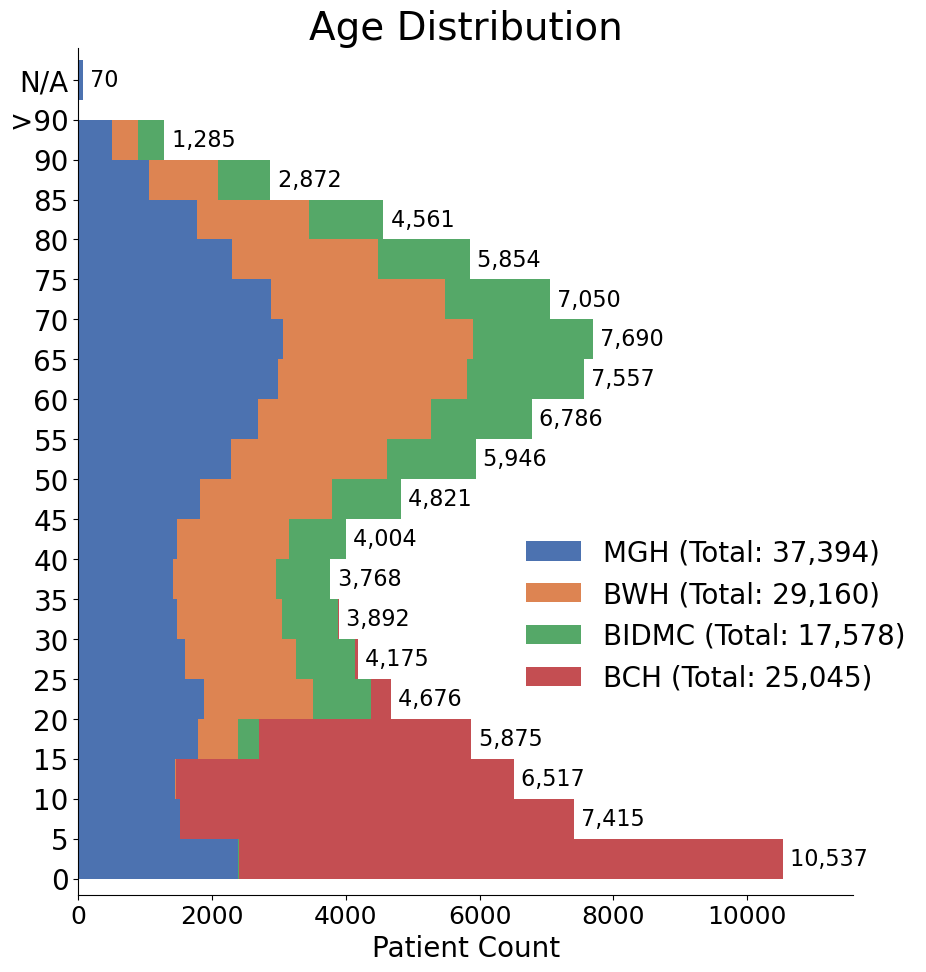

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

df_all = pd.read_csv('/Users/chenxisun/Downloads/HEEDB/heedb/heedb_patients.csv')
df_all.loc[df_all['AgeAtVisitAvg'] > 120, 'AgeAtVisitAvg'] = np.nan
df_all.loc[df_all['AgeAtVisitAvg'] > 90, 'AgeAtVisitAvg'] = 91
df_all = df_all.fillna(96)

files = ['S0001', 'S0002', 'I0002', 'I0003']
file_name = ['MGH', 'BWH', 'BIDMC', 'BCH']

out_dir = '/Users/chenxisun/Downloads/HEEDB/heedb'

sns.set_palette("deep")

bins = range(0, 101, 5)

bar_positions = np.arange(0, 100, 5) + 2.5
bar_positions[-1] = bar_positions[-1] + 2.5

combined_df = pd.DataFrame()
age_group_counts_list = []
total_counts = []

for i, file in enumerate(files):
    df = df_all[(df_all['SiteID'] == file)]
    mean_age_at_visit = df['AgeAtVisitAvg'].astype(float)
    age_groups = pd.cut(mean_age_at_visit, bins=bins)
    age_group_counts = age_groups.value_counts().sort_index()
    age_group_counts_list.append(age_group_counts)
    total_counts.append(len(df))
    combined_df = pd.concat([combined_df, df])

combined_mean_age_at_visit = combined_df['AgeAtVisitAvg'].astype(float)
combined_age_groups = pd.cut(combined_mean_age_at_visit, bins=bins)
combined_age_group_counts = combined_age_groups.value_counts().sort_index()

plt.figure(figsize=(10, 11))

left = np.zeros(len(bar_positions))
bars = []
for i, age_group_counts in enumerate(age_group_counts_list):
    bar = plt.barh(
        bar_positions,
        age_group_counts.values,
        height=5,
        left=left,
        color=sns.color_palette()[i % len(sns.color_palette())],
        align='center'
    )
    bars.append(bar)
    left += age_group_counts.values

for pos, total in zip(bar_positions, left):
    if total > 0:
        plt.text(
            total + 5,
            pos,
            f' {int(total):,}',
            ha='left',
            va='center',
            fontsize=16,
            color='black'
        )

plt.title('Age Distribution', fontsize=28)
plt.xlabel('Patient Count', fontsize=20)

yticks_positions = np.arange(0, 101, 5)
yticks_labels = []
for i in yticks_positions:
    if i <= 90:
        yticks_labels.append(str(i))
    elif i == 95:
        yticks_labels.append('>90')
    elif i == 100:
        yticks_labels.append('N/A')

plt.yticks(yticks_positions, yticks_labels, fontsize=20)
plt.xticks(fontsize=18)

plt.xlim(0, max(left) * 1.1)
plt.ylim(-2, 104)

sns.despine()

legend_labels = [f"{file} (Total: {total_count:,})" for file, total_count in zip(file_name, total_counts)]
plt.legend(
    [bar[0] for bar in bars],
    legend_labels,
    frameon=False,
    fontsize=20,
    loc='upper right',
    bbox_to_anchor=(1.1, 0.45)
)

output_file_path = os.path.join(out_dir, 'age_horizontal.png')
plt.savefig(output_file_path, dpi=900, bbox_inches='tight')
plt.show()
plt.close()

# Horizontal plot of findings

/var/folders/zy/xyng2q6d26l8w7cy180frh2r0000gn/T/ipykernel_91183/2452599797.py:50: DtypeWarning: Columns (37,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)
/var/folders/zy/xyng2q6d26l8w7cy180frh2r0000gn/T/ipykernel_91183/2452599797.py:50: DtypeWarning: Columns (36,37,42,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)
/var/folders/zy/xyng2q6d26l8w7cy180frh2r0000gn/T/ipykernel_91183/2452599797.py:50: DtypeWarning: Columns (25,35,36,38,40,41,50) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


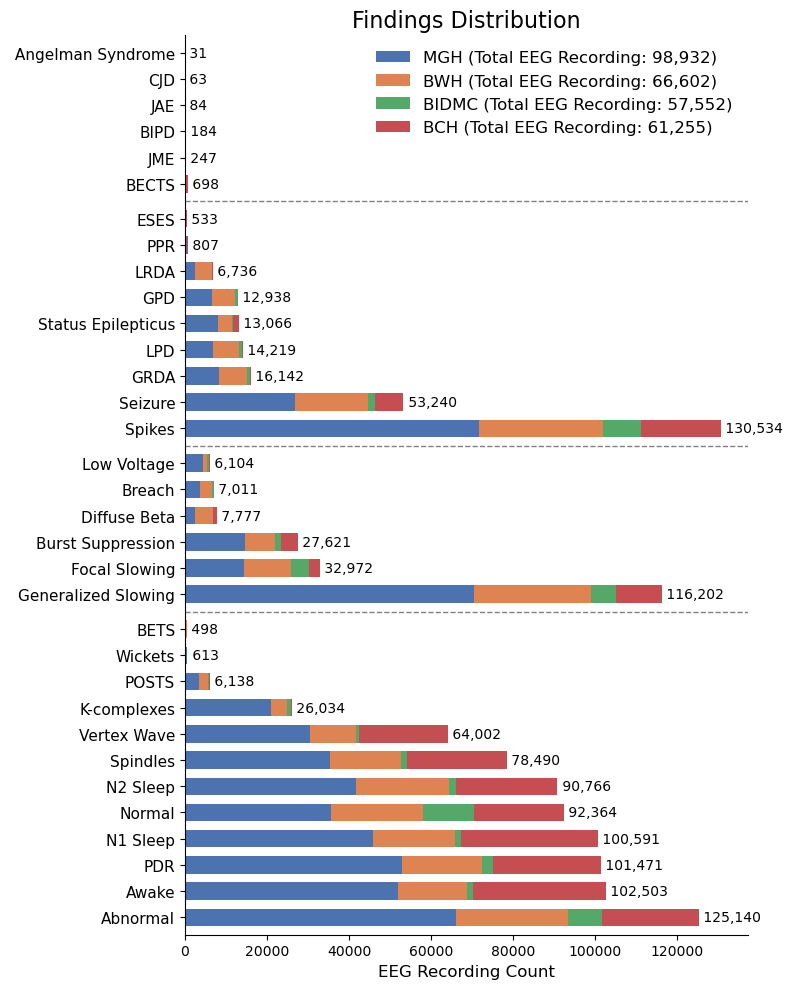

In [149]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

out_dir = '/Users/chenxisun/Downloads/HEEDB/heedb'

files = [
    '/Users/chenxisun/Downloads/HEEDB/heedb/MGH_EEG_with_reports4.csv',
    '/Users/chenxisun/Downloads/HEEDB/heedb/BWH_EEG_with_reports4.csv',
    '/Users/chenxisun/Downloads/HEEDB/heedb/BIDMC_EEG_with_reports3.csv',
    '/Users/chenxisun/Downloads/HEEDB/heedb/BCH_EEG_with_reports3.csv'
]

findings_order = [
    'abnormal', 'awake','pdr','n1','normal', 'n2','spindles','vertex wave','k_complexes','posts','wicket','bets',
    'gen slowing', 'foc slowing','bs', 'diffuse Beta','breach', 'low voltage',
    'spikes','seizure','grda', 'lpd','status', 'gpd', 'lrda', 'ppr','eses', 
    'bects','jme','bipd','jae', 'cjd', 'angelman'
]

x_labels = [
    'Abnormal', 'Awake','PDR','N1 Sleep','Normal','N2 Sleep','Spindles','Vertex Wave','K-complexes','POSTS','Wickets','BETS',
    'Generalized Slowing','Focal Slowing','Burst Suppression','Diffuse Beta','Breach','Low Voltage',
    'Spikes','Seizure','GRDA','LPD','Status Epilepticus','GPD','LRDA','PPR','ESES', 
    'BECTS','JME','BIPD','JAE','CJD','Angelman Syndrome'
]

group = {
    'Overall Impression and Normal Findings': ['Abnormal', 'Awake','PDR','N1 Sleep','Normal','N2 Sleep','Spindles','Vertex Wave','K-complexes','POSTS','Wickets','BETS'],
    'Background Abnormalities': ['Generalized Slowing','Focal Slowing','Burst Suppression','Diffuse Beta','Breach','Low Voltage'],
    'Epileptiform Abnormalities and Rhythmic Patterns': ['Spikes','Seizure','GRDA','LPD','Status Epilepticus','GPD','LRDA','PPR','ESES'],
    'Syndromes Mentioned in EEG Reports': ['BECTS','JME','BIPD','JAE','CJD','Angelman Syndrome']
}

findings_to_labels = dict(zip(findings_order, x_labels))

combined_df = pd.DataFrame()
findings_counts_list = []

for file in files:
    df = pd.read_csv(file)
    findings_counts = df[findings_order].notna().sum()
    findings_counts['normal'] += 11000

    findings_counts_list.append(findings_counts)
    combined_df = pd.concat([combined_df, df])

plt.figure(figsize=(8, 10))

bottom = np.zeros(len(findings_order))
bars = []
bar_positions = np.arange(len(findings_order)) * 1.5

group_boundaries = []
current_group_end = 0

for group_name, group_findings in group.items():
    group_end = current_group_end + len([f for f in findings_order if findings_to_labels[f] in group_findings])
    group_boundaries.append((current_group_end, group_end))
    current_group_end = group_end

for group_boundary in group_boundaries:
    bar_positions[group_boundary[-1]:] = bar_positions[group_boundary[-1]:] + 0.5

for i, findings_counts in enumerate(findings_counts_list):
    bar = plt.barh(
        bar_positions,
        findings_counts.values,
        left=bottom,
        height=1,
        color=sns.color_palette()[i % len(sns.color_palette())],
        align='center'
    )
    bars.append(bar)
    bottom += findings_counts.values

for start, end in group_boundaries[1:]:
    plt.axhline(bar_positions[start] - 1, color='gray', linestyle='--', linewidth=1)

for j, total in enumerate(bottom):
    if total > 0:
        plt.text(total + 5, bar_positions[j], f' {int(total):,}', ha='left', va='center', fontsize=10, color='black')

plt.title('Findings Distribution', fontsize=16)
plt.xlabel('EEG Recording Count', fontsize=12)
plt.yticks(bar_positions, [findings_to_labels[f] for f in findings_order], fontsize=11)
plt.xticks(fontsize=10)
plt.ylim(bottom=bar_positions[0] - 1, top=bar_positions[-1] + 1)

sns.despine(right=True, top=True)

legend_labels = [
    f"{os.path.basename(file).split('_')[0]} (Total EEG Recording: {total_count})"
    for file, total_count in zip(files, ['98,932', '66,602', '57,552', '61,255'])
]

handles = [bar[0] for bar in bars]

plt.legend(handles, legend_labels, frameon=False, loc='upper right', fontsize=12)

plt.tight_layout()

output_file_path = os.path.join(out_dir, 'findings_horizontal.png')
plt.savefig(output_file_path, dpi=500, bbox_inches='tight')
plt.show()
plt.close()

# race

In [444]:
heedb_patients=pd.read_csv('/Users/chenxisun/Desktop/heedb/heedb_patients.csv')
heedb_patients['RaceAndEthnicity']=''
heedb_patients['RaceAndEthnicityDSC']=''
heedb_patients = heedb_patients[['SiteID', 'BDSPPatientID', 'SexDSC', 'AgeAtVisitAvg', 'RaceAndEthnicity','RaceAndEthnicityDSC', 'VisitCount','HasEEG','HasReports','MatchedEEGReports']]

In [445]:
heedb_patients

,SiteID,BDSPPatientID,SexDSC,AgeAtVisitAvg,RaceAndEthnicity,RaceAndEthnicityDSC,VisitCount,HasEEG,HasReports,MatchedEEGReports
0,S0001,111189188,F,23.0,,,6.0,Y,Y,Y
1,S0001,111189302,F,78.0,,,3.0,Y,Y,Y
2,S0001,111189591,F,35.0,,,1.0,Y,Y,Y
3,S0001,111189719,M,52.0,,,2.0,Y,Y,Y
4,S0001,111189925,F,40.0,,,1.0,Y,Y,Y
...,...,...,...,...,...,...,...,...,...,...
109172,I0003,175945481,M,0.0,,,1.0,Y,Y,Y
109173,I0003,175945484,F,0.0,,,2.0,Y,Y,Y
109174,I0003,175945485,M,0.0,,,3.0,Y,Y,Y
109175,I0003,175945486,M,0.0,,,5.0,Y,Y,Y


In [446]:
demo_df_mgb = pd.read_parquet('/Users/chenxisun/cdac Dropbox/Datasets/BDSP_deID/I0001-MGB/data_Structured/Parquet/MGB_Carolina_ParquetFiles/patient/patient_eeg_psg_only.parquet')
demo_df_mgb['RaceAndEthnicity'] = demo_df_mgb['PatientRace'] + ', ' + demo_df_mgb['EthnicGroupDSC']
print(demo_df_mgb.columns)

demo_df_bch = pd.read_parquet('/Users/chenxisun/cdac Dropbox/Datasets/BDSP_deID/I0003-BCH/data_Structured/Parquet/BCH_ParquetFiles_2024_10_30/patient/I0003_patient_eeg_psg_only_10312024.parquet')
demo_df_bch['RaceAndEthnicity'] = demo_df_bch['Race'] + ', ' + demo_df_bch['Ethnicity']
print(demo_df_bch.columns)

dir_path='/Users/chenxisun/cdac Dropbox/Datasets/BDSP_deID/I0002-BIDMC/data_Structured/Parquet/BIDMC_batch1/BIDMC_Thunderpack_Raw_Data_Parquets/patient_nax_parquet/'
combined_df = pd.DataFrame()
parquet_files = list(Path(dir_path).glob('*.parquet'))
dfs = [pd.read_parquet(file) for file in parquet_files]
combined_df = pd.concat(dfs, ignore_index=True)
demo_df_bidmc = combined_df.drop_duplicates(subset='BDSPPatientID')
demo_df_bidmc['RaceAndEthnicity'] = demo_df_bidmc['PatientRace'] + ', ' + demo_df_bidmc['EthnicGroupDSC']
print(demo_df_bidmc.columns)

Index(['BDSPPatientID', 'DateOfBirth', 'DateOfDeath',
       'DateOfDeathMARegistryData', 'PatientRace', 'EthnicGroupDSC',
       'MaritalStatusDSC', 'ReligionDSC', 'LanguageDSC', 'VeteranStatusDSC',
       'SexDSC', 'PrimaryCauseOfDeathDSC', 'UNOSPrimaryCauseOfDeathTXT',
       'FirstContributoryCauseOfDeathDSC', 'UNOSContributoryCauseOfDeath01TXT',
       'SecondContributoryCauseOfDeathDSC',
       'UNOSContributoryCauseOfDeath02TXT', 'EducationLevelDSC',
       'GenderIdentityDSC', 'SexAssignedAtBirthDSC', 'BDSPLastModifiedDTS',
       'RaceAndEthnicity'],
      dtype='object')
Index(['BDSPPatientID', 'BirthDate', 'DateOfDeathMARegistryData', 'Gender',
       'Race', 'Ethnicity', 'Language', 'Country', 'BDSPLastModifiedDTS',
       'RaceAndEthnicity'],
      dtype='object')
Index(['BDSPPatientID', 'PatientRace', 'EthnicGroupDSC', 'MaritalStatusDSC',
       'ReligionDSC', 'LanguageDSC', 'SexDSC', 'BDSPLastModifiedDTS',
       'RaceAndEthnicity'],
      dtype='object')


/var/folders/zy/xyng2q6d26l8w7cy180frh2r0000gn/T/ipykernel_65782/3621909860.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo_df_bidmc['RaceAndEthnicity'] = demo_df_bidmc['PatientRace'] + ', ' + demo_df_bidmc['EthnicGroupDSC']


In [447]:
mapping_mgb = demo_df_mgb.set_index('BDSPPatientID')['RaceAndEthnicity'].to_dict()
mapping_bch = demo_df_bch.set_index('BDSPPatientID')['RaceAndEthnicity'].to_dict()
mapping_bidmc = demo_df_bidmc.set_index('BDSPPatientID')['RaceAndEthnicity'].to_dict()
merged_dict = {**mapping_mgb, **mapping_bch, **mapping_bidmc}
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['BDSPPatientID'].map(merged_dict)

In [448]:
heedb_patients

,SiteID,BDSPPatientID,SexDSC,AgeAtVisitAvg,RaceAndEthnicity,RaceAndEthnicityDSC,VisitCount,HasEEG,HasReports,MatchedEEGReports
0,S0001,111189188,F,23.0,,"Black or African American, Not Hispanic",6.0,Y,Y,Y
1,S0001,111189302,F,78.0,,"White, Unavailable",3.0,Y,Y,Y
2,S0001,111189591,F,35.0,,"White, Not Hispanic",1.0,Y,Y,Y
3,S0001,111189719,M,52.0,,"White, Unavailable",2.0,Y,Y,Y
4,S0001,111189925,F,40.0,,"White, Not Hispanic",1.0,Y,Y,Y
...,...,...,...,...,...,...,...,...,...,...
109172,I0003,175945481,M,0.0,,"Unknown, Unable to Collect",1.0,Y,Y,Y
109173,I0003,175945484,F,0.0,,"White, non-Hispanic, American",2.0,Y,Y,Y
109174,I0003,175945485,M,0.0,,"White, non-Hispanic, English",3.0,Y,Y,Y
109175,I0003,175945486,M,0.0,,"Another Race, non-Hispanic, American Indian",5.0,Y,Y,Y


In [449]:
counts = heedb_patients['RaceAndEthnicityDSC'].unique()
print(counts)

[' Black or African American, Not Hispanic' ' White, Unavailable'
 ' White, Not Hispanic' ' Other, Hispanic'
 ' Black or African American, Hispanic' ' Declined, Not Hispanic'
 ' Other; White, Hispanic' ' Asian, Not Hispanic' ' Other, Unavailable'
 ' Unavailable, Unavailable' ' Unavailable, Hispanic'
 ' White, No Non Hispanic' ' Unavailable; White, Not Hispanic'
 ' White, Hispanic' ' Unavailable; White, Unavailable'
 ' Black or African American; White, Not Hispanic'
 ' Unavailable, Not Hispanic'
 ' Black or African American; Other, Hispanic' nan ' Other, Not Hispanic'
 ' Black or African American, Unavailable'
 ' Asian, Prefer not to say/Decline' ' Asian, Unavailable'
 ' Asian; White, Not Hispanic' ' Other, Yes Hispanic'
 ' Black or African American; Other, Not Hispanic'
 ' American Indian or Alaska Native, Not Hispanic'
 ' Other; White, Not Hispanic' ' Other; Unavailable, Not Hispanic'
 ' Declined, Unavailable' ' Black or African American, No Non Hispanic'
 ' White, Prefer not to say/D

In [456]:
key_race=['White','Black or African American','American Indian or Alaska Native','Asian','Native Hawaiian or Other Pacific Islander']



def format_title_case(text):
    if pd.isna(text):
        return text
    text = str(text)
    if text.isupper():
        text = text.title()
    text = text.replace('/', ' or ')
    text = text.replace(';', ',')
    parts = [part.strip() for part in str(text).split(',')]
    return ', '.join(set(parts))

def strip_text(value):
    if isinstance(value, str):
        return value.strip()
    return value

def remove_trailing_comma(text):
    if pd.isna(text):
        return text
    text = str(text).rstrip(',')
    return text

def process_unavailable_other(text):
    if pd.isna(text) or text.strip() == '':
        return 'Unavailable'
    parts = [part.strip() for part in str(text).split(',')]
    if len(set(parts)) == 1 and parts[0] == 'Unavailable':
        return 'Unavailable'
    if len(set(parts)) == 1 and parts[0] == 'Other':
        return 'Other'
    parts = [part for part in parts if part != 'Unavailable']
    if 'Other' in parts and len(set(parts) & set(key_race)) > 0:
        parts = [part for part in parts if part != 'Other']
        return ', '.join(parts)
    return ', '.join(parts)

def process_Hispanic(text):
    parts = [part.strip() for part in str(text).split(',')]
    parts = [part for i, part in enumerate(parts) if part != 'Hispanic' or 'Hispanic' not in parts[:i]]
    return ', '.join(parts)
    parts = [part for i, part in enumerate(parts) if part != 'non-Hispanic' or 'non-Hispanic' not in parts[:i]]
    return ', '.join(parts)

def process_Black(text):
    parts = [part.strip() for part in str(text).split(',')]
    parts = ['Black or African American' if part == 'Black' or part == 'African American' else part for part in parts]
    return ', '.join(parts)

def process_American_Indian(text):
    parts = [part.strip() for part in str(text).split(',')]
    parts = ['American Indian or Alaska Native' if part == 'American Indian' or part == 'Alaska Native' else part for part in parts]
    return ', '.join(parts)
    
def process_Native_Hawaiian(text):
    parts = [part.strip() for part in str(text).split(',')]
    parts = ['Native Hawaiian or Other Pacific Islander' if part == 'Native Hawaiian' or part == 'Pacific Islander' or part == 'Hawaiian' else part for part in parts]
    return ', '.join(parts)

def clean_text(text):
    parts = [part.strip() for part in str(text).split(',')]
    return ', '.join(set(parts))
    
heedb_patients = heedb_patients.applymap(strip_text)

heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Not Hispanic', 'non-Hispanic', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('No Non Hispanic', 'non-Hispanic', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Yes Hispanic', 'Hispanic', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Race not listed', 'Unavailable', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Prefer not to say/Decline', 'Decline', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].apply(format_title_case)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Other Race', 'Other', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Unknown or Not Specified', 'Unavailable', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Prefer Not To Say', 'Decline', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace("Patient doesn't know", 'Unavailable', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Unable To Obtain', 'Unavailable', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('AnOther', 'Other', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Declined to Answer', 'Decline', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Unknown', 'Unavailable', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Choose not to answer', 'Unavailable', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace("Don't know", 'Unavailable', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('American (USA)', 'American', case=False)

heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Decline', 'Unavailable', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('South American (Not Otherwise Specified)', 'South American', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Central American (Not Otherwise Specified)', 'Central American', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Dominican (Republic)', 'Dominican', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Unavailabled', 'Unavailable', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Unavailable, Unavailable, Unavailable', 'Unavailable', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Unavailable, Unavailable', 'Unavailable', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Unable to Collect', 'Unavailable', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Other Ethnicity', 'Other', case=False)

heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Native Hawaiian and Other Pacific Islander', 'Native Hawaiian or Other Pacific Islander', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Native Hawaiian And Other Pacific Islander', 'Native Hawaiian or Other Pacific Islander', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Native Hawaiian Or Other Pacific Islander', 'Native Hawaiian or Other Pacific Islander', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].apply(process_Native_Hawaiian)


heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('American Indian and Alaska Native', 'American Indian or Alaska Native', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('American Indian And Alaska Native', 'American Indian or Alaska Native', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('American Indian Or Alaska Native', 'American Indian or Alaska Native', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].apply(process_American_Indian)

heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Black and African American', 'Black or African American', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Black And African American', 'Black or African American', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Black Or African American', 'Black or African American', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].apply(process_Black)

heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Hispanic or Latino', 'Hispanic', case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Latino', 'Hispanic',case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('Hispanic, non-Hispanic', 'Hispanic',case=False)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].str.replace('non-Hispanic, Hispanic', 'Hispanic',case=False)

heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].apply(process_unavailable_other)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].apply(process_Hispanic)

heedb_patients = heedb_patients.applymap(strip_text)
heedb_patients['RaceAndEthnicityDSC'] = heedb_patients['RaceAndEthnicityDSC'].apply(remove_trailing_comma)
heedb_patients = heedb_patients.applymap(clean_text)

In [457]:
counts = heedb_patients['RaceAndEthnicityDSC'].unique()
print(counts)

['Black or African American, non-Hispanic' 'White' 'White, non-Hispanic'
 'Other, Hispanic' 'Black or African American, Hispanic' 'non-Hispanic'
 'White, Hispanic' 'Asian, non-Hispanic' 'Other' 'Unavailable' 'Hispanic'
 'Black or African American, White, non-Hispanic' 'nan'
 'Other, non-Hispanic' 'Black or African American' 'Asian'
 'Asian, White, non-Hispanic'
 'American Indian or Alaska Native, non-Hispanic' 'Asian, White'
 'Black or African American, White, Hispanic'
 'Asian, Black or African American, non-Hispanic'
 'American Indian or Alaska Native, Black or African American, Hispanic'
 'American Indian or Alaska Native, White, non-Hispanic'
 'Native Hawaiian or Other Pacific Islander'
 'Black or African American, White' 'American Indian or Alaska Native'
 'American Indian or Alaska Native, Black or African American, non-Hispanic'
 'American Indian or Alaska Native, White'
 'Native Hawaiian or Other Pacific Islander, White'
 'Asian, Black or African American'
 'American Indian or 

In [458]:
key_race = [
    'White', 
    'Black or African American', 
    'American Indian or Alaska Native', 
    'Asian', 
    'Native Hawaiian or Other Pacific Islander',
    'Multiracial'
]

race_mapping = {
    'White': 'White',
    'Black or African American': 'Black or African American',
    'American Indian or Alaska Native': 'American Indian or Alaska Native',
    'Asian': 'Asian',
    'Native Hawaiian or Other Pacific Islander': 'Native Hawaiian or Other Pacific Islander',
    'Multiracial': 'Multiracial'
}

def fill_race_and_ethnicity(row):
    if pd.isna(row) or row.strip() == '':
        return 'Unavailable'
    parts = [part.strip() for part in row.split(',')]
    races_in_key = [part for part in parts if part in key_race]
    if len(races_in_key) == 1:
        return race_mapping[races_in_key[0]]
    if len(races_in_key) > 1:
        return 'Multiracial'
    if 'Other' in parts:
        return 'Other Race'
    return 'Unavailable'

heedb_patients['RaceAndEthnicity'] = heedb_patients['RaceAndEthnicityDSC'].apply(fill_race_and_ethnicity)
heedb_patients

,SiteID,BDSPPatientID,SexDSC,AgeAtVisitAvg,RaceAndEthnicity,RaceAndEthnicityDSC,VisitCount,HasEEG,HasReports,MatchedEEGReports
0,S0001,111189188,F,23.0,Black or African American,"Black or African American, non-Hispanic",6.0,Y,Y,Y
1,S0001,111189302,F,78.0,White,White,3.0,Y,Y,Y
2,S0001,111189591,F,35.0,White,"White, non-Hispanic",1.0,Y,Y,Y
3,S0001,111189719,M,52.0,White,White,2.0,Y,Y,Y
4,S0001,111189925,F,40.0,White,"White, non-Hispanic",1.0,Y,Y,Y
...,...,...,...,...,...,...,...,...,...,...
109172,I0003,175945481,M,0.0,Unavailable,Unavailable,1.0,Y,Y,Y
109173,I0003,175945484,F,0.0,White,"American, White, non-Hispanic",2.0,Y,Y,Y
109174,I0003,175945485,M,0.0,White,"White, English, non-Hispanic",3.0,Y,Y,Y
109175,I0003,175945486,M,0.0,American Indian or Alaska Native,"American Indian or Alaska Native, non-Hispanic",5.0,Y,Y,Y


# Horizontal plot of race

In [183]:
df_all = pd.read_csv('/Users/chenxisun/Downloads/HEEDB/heedb/HEEDB_patients.csv')
df_all['Hispanic'] = df_all['RaceAndEthnicityDSC'].apply(
    lambda x: 'Y' if 'Hispanic' in str(x) and 'non-Hispanic' not in str(x) else 
              'N' if 'non-Hispanic' in str(x) else None
)
df_all=df_all[['SiteID', 'BDSPPatientID', 'Sex', 'AgeAtVisitAvg', 'RaceAndEthnicity','Hispanic',
       'RaceAndEthnicityDSC', 'VisitCount', 'HasEEG', 'HasReports',
       'MatchedEEGReports', 'ICD10Count', 'MedicationCount']]

In [184]:
df_all.to_csv('/Users/chenxisun/Downloads/HEEDB/heedb/HEEDB_patients.csv',index=False)

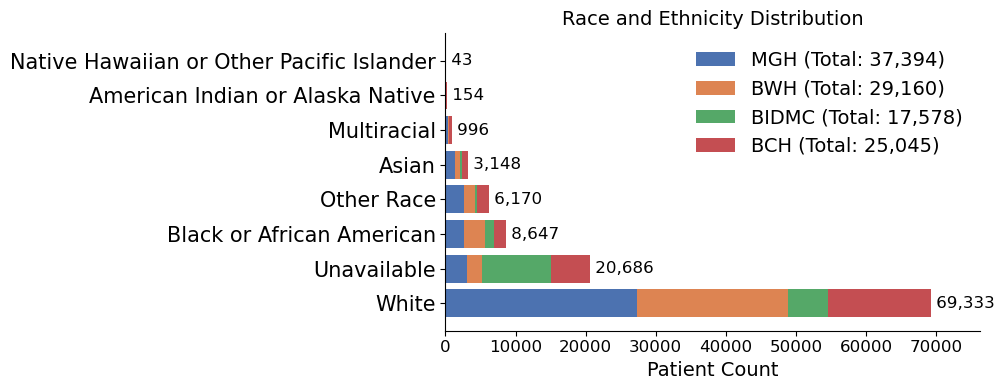

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

df_all = pd.read_csv('/Users/chenxisun/Downloads/HEEDB/heedb/HEEDB_patients.csv')

SiteID = ['S0001', 'S0002', 'I0002', 'I0003']
file_name = ['MGH', 'BWH', 'BIDMC', 'BCH']

out_dir = '/Users/chenxisun/Downloads/HEEDB/heedb'
os.makedirs(out_dir, exist_ok=True)

sns.set_palette("deep")

race_counts_list = []
site_totals = []
for site in SiteID:
    df_site = df_all[df_all['SiteID'] == site]
    race_counts = df_site['RaceAndEthnicity'].value_counts()
    race_counts_list.append(race_counts)
    site_totals.append(df_site.shape[0])

unique_races = df_all['RaceAndEthnicity'].dropna().unique()

race_df = pd.DataFrame(index=unique_races)
for i, race_counts in enumerate(race_counts_list):
    race_df[file_name[i]] = race_counts

race_df = race_df.fillna(0)

race_df['Total'] = race_df.sum(axis=1)
race_df = race_df.sort_values(by='Total', ascending=False)
race_df = race_df.drop(columns=['Total'])

plt.figure(figsize=(10, 5))

left = np.zeros(len(race_df))
bars = []
for i, site in enumerate(file_name):
    bar = plt.barh(race_df.index, race_df[site], left=left,
                   label=f"{site} (Total: {site_totals[i]:,})")
    bars.append(bar)
    left += race_df[site]

for race, total in zip(race_df.index, left):
    plt.text(total + 5, race, f' {int(total):,}',
             ha='left', va='center', fontsize=12, color='black')

plt.title('Race and Ethnicity Distribution', fontsize=14)
plt.xlabel('Patient Count', fontsize=14)

plt.yticks(fontsize=15)
plt.xticks(fontsize=12)

plt.xlim(0, max(left) * 1.1)

sns.despine()

plt.legend(loc='upper right', fontsize=14, frameon=False)

plt.tight_layout()

output_file_path = os.path.join(out_dir, 'race_horizontal.png')
plt.savefig(output_file_path, dpi=300, bbox_inches='tight')

plt.show()
plt.close()

# with Hispanic

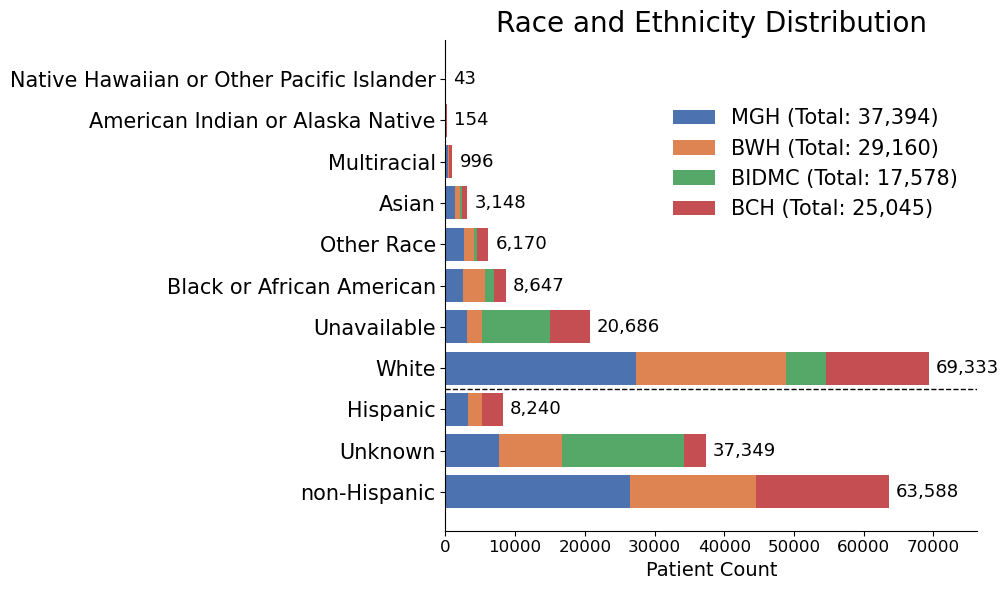

In [146]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

df_all = pd.read_csv('/Users/chenxisun/Downloads/HEEDB/heedb/HEEDB_patients.csv')

SiteID = ['S0001', 'S0002', 'I0002', 'I0003']
file_name = ['MGH', 'BWH', 'BIDMC', 'BCH']

out_dir = '/Users/chenxisun/Downloads/HEEDB/heedb'
os.makedirs(out_dir, exist_ok=True)

sns.set_palette("deep")

race_counts_list = []
hispanic_counts_list = []
site_totals = []

for site in SiteID:
    df_site = df_all[df_all['SiteID'] == site]
    race_counts = df_site['RaceAndEthnicity'].value_counts()
    race_counts_list.append(race_counts)
    hispanic_counts = df_site['Hispanic'].fillna('Unknown').replace({'Y': 'Hispanic', 'N': 'non-Hispanic'}).value_counts()
    hispanic_counts_list.append(hispanic_counts)
    site_totals.append(df_site.shape[0])

unique_races = df_all['RaceAndEthnicity'].dropna().unique()
race_df = pd.DataFrame(index=unique_races)
for i, race_counts in enumerate(race_counts_list):
    race_df[file_name[i]] = race_counts
race_df = race_df.fillna(0)
race_df['Total'] = race_df.sum(axis=1)
race_df = race_df.sort_values(by='Total', ascending=False)
race_df = race_df.drop(columns=['Total'])

hispanic_order = ['non-Hispanic', 'Unknown', 'Hispanic']
hispanic_df = pd.DataFrame(index=hispanic_order)
for i, hispanic_counts in enumerate(hispanic_counts_list):
    hispanic_df[file_name[i]] = hispanic_counts
hispanic_df = hispanic_df.fillna(0)

combined_df = pd.concat([hispanic_df, race_df])
split_index = len(race_df)

plt.figure(figsize=(10, 6))
left = np.zeros(len(combined_df))
bars = []

for i, site in enumerate(file_name):
    bar = plt.barh(combined_df.index, combined_df[site], left=left, height=0.8, label=f"{site} (Total: {site_totals[i]:,})")
    bars.append(bar)
    left += combined_df[site]

for idx, total in zip(combined_df.index, left):
    plt.text(total + 1000, idx, f'{int(total):,}', ha='left', va='center', fontsize=13)

y_positions = np.arange(len(combined_df))
if split_index < len(y_positions):
    y_sep = (-y_positions[split_index] + y_positions[split_index+2] + 0.5)
    plt.axhline(y=y_sep, color='black', linestyle='--', linewidth=1)

plt.title('Race and Ethnicity Distribution', fontsize=20)
plt.xlabel('Patient Count', fontsize=14)
plt.yticks(fontsize=15)
plt.xticks(fontsize=12)
plt.xlim(0, max(left) * 1.1)
sns.despine()
plt.legend(loc='upper right', bbox_to_anchor=(1, 0.9), fontsize=15, frameon=False)

plt.tight_layout()

output_file_path = os.path.join(out_dir, 'race_and_hispanic_separated.png')
plt.savefig(output_file_path, dpi=500, bbox_inches='tight')
plt.show()
plt.close()

# ICD longitudinal plot

/var/folders/zy/xyng2q6d26l8w7cy180frh2r0000gn/T/ipykernel_91183/1822645114.py:7: DtypeWarning: Columns (6,8,9,15,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv('/Users/chenxisun/Downloads/HEEDB/heedb/HEEDB_ICD10_for_Neurology.csv')


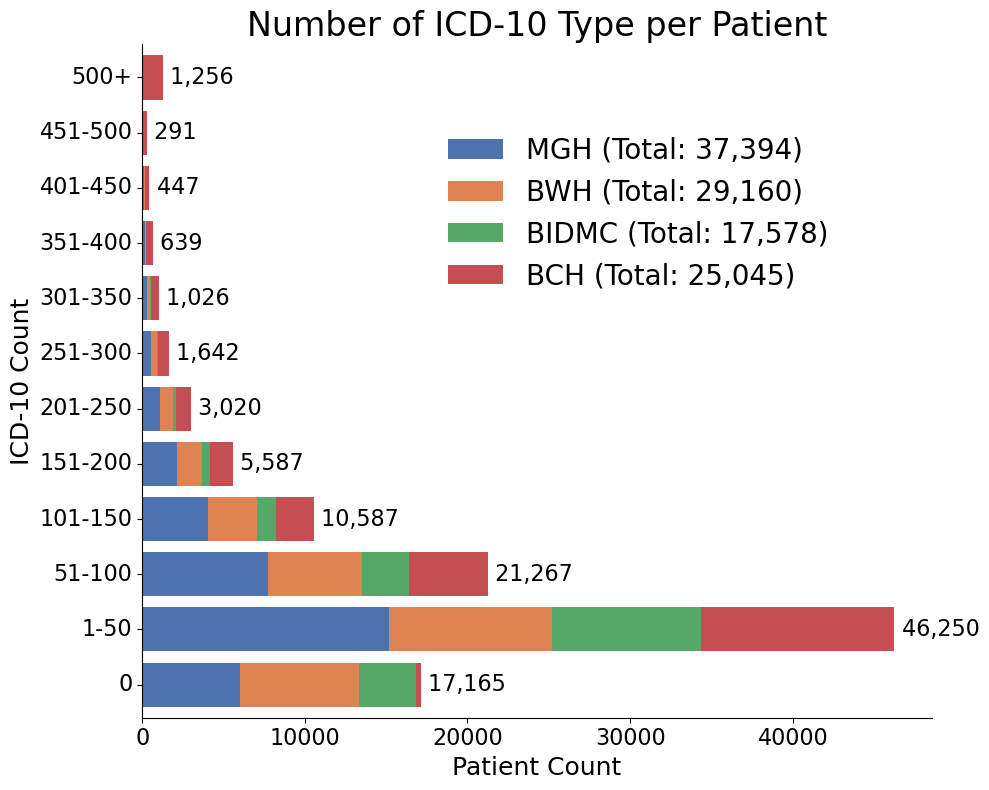

图表已保存到: /Users/chenxisun/Downloads/HEEDB/heedb/ICD10TypeCount_distribution_horizontal.png


In [180]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_all = pd.read_csv('/Users/chenxisun/Downloads/HEEDB/heedb/HEEDB_ICD10_for_Neurology.csv')

files = ['S0001', 'S0002', 'I0002', 'I0003']
file_name = ['MGH', 'BWH', 'BIDMC', 'BCH']

out_dir = '/Users/chenxisun/Downloads/HEEDB/heedb'

sns.set_palette("deep")

bins = [0, 1, 51, 101, 151, 201, 251, 301, 351, 401, 451, 501, np.inf]

bin_labels = [
    '0', '1-50', '51-100', '101-150', '151-200', '201-250',
    '251-300', '301-350', '351-400', '401-450', '451-500', '500+'
]

bar_positions = np.arange(len(bin_labels)) + 0.5

combined_df = pd.DataFrame()
icd10_counts_list = []
total_counts = []

for i, file in enumerate(files):
    df = df_all[(df_all['SiteID'] == file)]
    icd10_counts = df['ICD10_type_count'].astype(float)
    icd10_groups = pd.cut(icd10_counts, bins=bins, labels=bin_labels, right=False)
    icd10_group_counts = icd10_groups.value_counts().sort_index()
    icd10_counts_list.append(icd10_group_counts)
    total_counts.append(len(df))
    combined_df = pd.concat([combined_df, df])

combined_icd10_counts = combined_df['ICD10_type_count'].astype(float)
combined_icd10_groups = pd.cut(combined_icd10_counts, bins=bins, labels=bin_labels, right=False)
combined_icd10_group_counts = combined_icd10_groups.value_counts().sort_index()

plt.figure(figsize=(10, 8))

left = np.zeros(len(bar_positions))
bars = []

for i, icd10_counts in enumerate(icd10_counts_list):
    bar = plt.barh(
        bar_positions, icd10_counts.values, height=0.8, left=left,
        color=sns.color_palette()[i % len(sns.color_palette())], align='center'
    )
    bars.append(bar)
    left += icd10_counts.values

for pos, total in zip(bar_positions, left):
    if total > 0:
        plt.text(total + 5, pos, f' {int(total):,}',
                 ha='left', va='center', fontsize=16, color='black')

plt.title('Number of ICD-10 Type per Patient', fontsize=24)
plt.ylabel('ICD-10 Count', fontsize=18)
plt.xlabel('Patient Count', fontsize=18)

plt.yticks(bar_positions, bin_labels, va='center', fontsize=16)
plt.xticks(fontsize=16)

plt.ylim(bottom=bar_positions[0] - 0.6, top=bar_positions[-1] + 0.6)

sns.despine()

legend_labels = [
    f"{file} (Total: {total_count:,})"
    for file, total_count in zip(file_name, total_counts)
]

plt.legend(
    [bar[0] for bar in bars], legend_labels, frameon=False,
    fontsize=20, loc='upper right', bbox_to_anchor=(0.9, 0.9)
)

plt.tight_layout()

output_file_path = os.path.join(out_dir, 'ICD10TypeCount_distribution_horizontal.png')
plt.savefig(output_file_path, dpi=500, bbox_inches='tight')
plt.show()
plt.close()

print(f"图表已保存到: {output_file_path}")

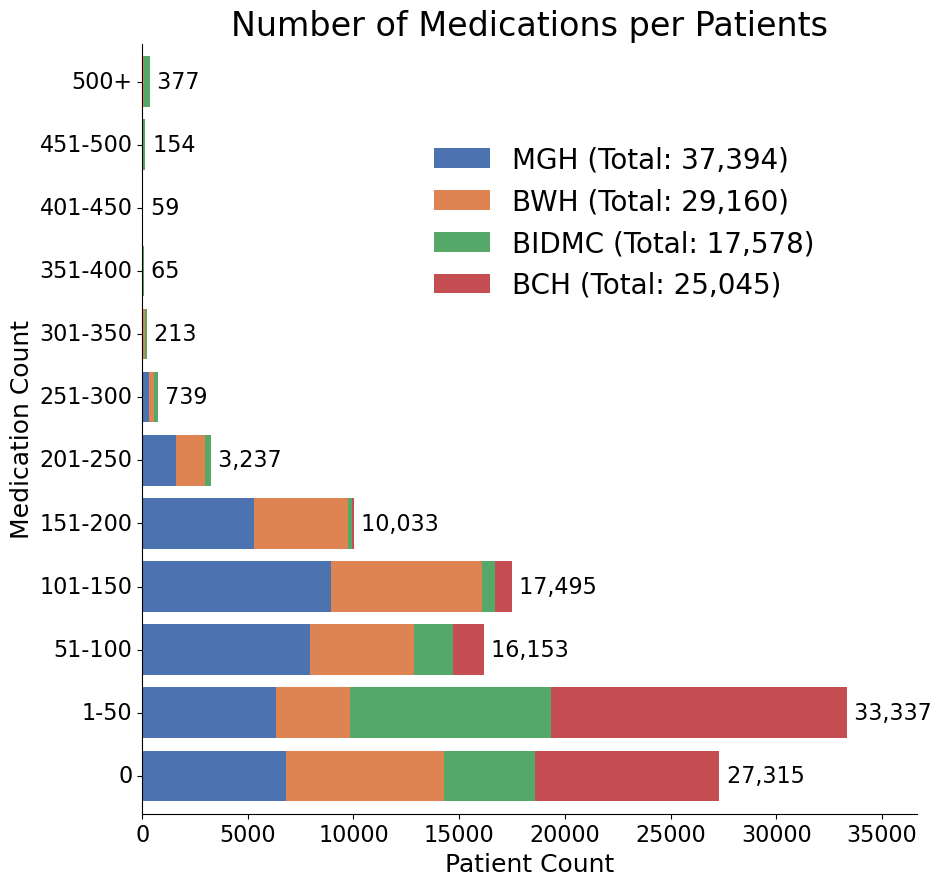

图表已保存到: /Users/chenxisun/Downloads/HEEDB//heedb/MedicationCount_distribution_horizontal.png


In [188]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_all = pd.read_csv('/Users/chenxisun/Downloads/HEEDB/heedb/HEEDB_patients.csv')

files = ['S0001', 'S0002', 'I0002', 'I0003']
file_name = ['MGH', 'BWH', 'BIDMC', 'BCH']

out_dir = '/Users/chenxisun/Downloads/HEEDB/heedb'
os.makedirs(out_dir, exist_ok=True)

sns.set_palette("deep")

bins = [0, 1, 51, 101, 151, 201, 251, 301, 351, 401, 451, 501, np.inf]
bin_labels = [
    '0', '1-50', '51-100', '101-150', '151-200', '201-250',
    '251-300', '301-350', '351-400', '401-450', '451-500', '500+'
]

bar_positions = np.arange(len(bin_labels)) + 0.5

combined_df = pd.DataFrame()
medication_counts_list = []
total_counts = []

for i, file in enumerate(files):
    df = df_all[(df_all['SiteID'] == file)]
    medication_counts = df['MedicationCount'].astype(float)
    medication_groups = pd.cut(medication_counts, bins=bins, labels=bin_labels, right=False)
    medication_group_counts = medication_groups.value_counts().sort_index()
    medication_counts_list.append(medication_group_counts)
    total_counts.append(len(df))
    combined_df = pd.concat([combined_df, df])

combined_medication_counts = combined_df['MedicationCount'].astype(float)
combined_medication_groups = pd.cut(combined_medication_counts, bins=bins, labels=bin_labels, right=False)
combined_medication_group_counts = combined_medication_groups.value_counts().sort_index()

plt.figure(figsize=(10, 10))

left = np.zeros(len(bar_positions))
bars = []

for i, medication_counts in enumerate(medication_counts_list):
    bar = plt.barh(
        bar_positions, medication_counts.values, height=0.8, left=left,
        color=sns.color_palette()[i % len(sns.color_palette())], align='center'
    )
    bars.append(bar)
    left += medication_counts.values

for pos, total in zip(bar_positions, left):
    if total > 0:
        plt.text(total + 5, pos, f' {int(total):,}',
                 ha='left', va='center', fontsize=16, color='black')

plt.title('Number of Medications per Patients', fontsize=24)
plt.xlabel('Patient Count', fontsize=18)
plt.ylabel('Medication Count', fontsize=18)

plt.yticks(bar_positions, bin_labels, va='center', fontsize=16)
plt.xticks(fontsize=16)

plt.xlim(0, max(left) * 1.1)
plt.ylim(bottom=bar_positions[0] - 0.6, top=bar_positions[-1] + 0.6)

sns.despine()

legend_labels = [
    f"{file} (Total: {total_count:,})"
    for file, total_count in zip(file_name, total_counts)
]

plt.legend(
    [bar[0] for bar in bars], legend_labels, frameon=False,
    fontsize=20, loc='upper right', bbox_to_anchor=(0.9, 0.9)
)

output_file_path = os.path.join(out_dir, 'MedicationCount_distribution_horizontal.png')
plt.savefig(output_file_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"图表已保存到: {output_file_path}")

# Count the number of different medication types used by each patient.

In [151]:
import pandas as pd

medication_df = pd.read_csv('/Users/chenxisun/Downloads/HEEDB/heedb/HEEDB_Medication_ATC2_20250205.csv')

columns_to_process = medication_df.columns[5:]

def count_elements(row):
    total = 0
    for column in columns_to_process:
        if pd.notna(row[column]):
            total += len(str(row[column]).split())
    return total

medication_df['total'] = medication_df.apply(count_elements, axis=1)
medication_df

,BDSPPatientID,SiteID,SexDSC,VisitCount,AgeAtVisitAvg,Alimentary Tract And Metabolism Drugs,Antiinfectives For Systemic Use,Antineoplastic And Immunomodulating Agents,"Antiparasitic Products, Insecticides And Repellents",Blood And Blood Forming Organ Drugs,Cardiovascular System Drugs,Dermatologicals,Genito Urinary System And Sex Hormones,Musculo-Skeletal System Drugs,Nervous System Drugs,Respiratory System Drugs,Sensory Organ Drugs,"Systemic Hormonal Preparations, Excl. Sex Hormones And Insulins",Various Drug Classes In Atc,total
0,111189151,S0002,F,1.0,95.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,111189188,S0001,F,6.0,23.0,A10AF A12CD A12AA A02AD A10AD A10AE A01AD A03A...,J07AL,NaN,NaN,B01AB B03XA B05AA,C03CA C08CA C07AG C01CA C07AB,NaN,NaN,M03AC,N02AA N01AX N02AB N01AH N03AX N05BA,NaN,NaN,NaN,V08AB,45
2,111189302,S0001,F,3.0,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,111189586,S0002,M,1.0,39.0,NaN,NaN,NaN,NaN,NaN,C10AA,NaN,NaN,M03BX,N03AF N02AA,NaN,NaN,NaN,NaN,4
4,111189591,S0001,F,1.0,35.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108661,121100791,S000X,NaN,NaN,NaN,A12CD A12AA A02AD A12CC A03FA A06AG A02AB A16A...,J01DD,NaN,NaN,B02BD B03XA B05AA B02BC,C02DB C08CA C07AG,NaN,G03AD G03AC,M03AC,N02AA N01AX N05CD N02AB N02BF N05AB N03AX N01AH,NaN,NaN,NaN,V08CA,43
108662,115137065,S000X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
108663,115413409,S000X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
108664,114232161,S000X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


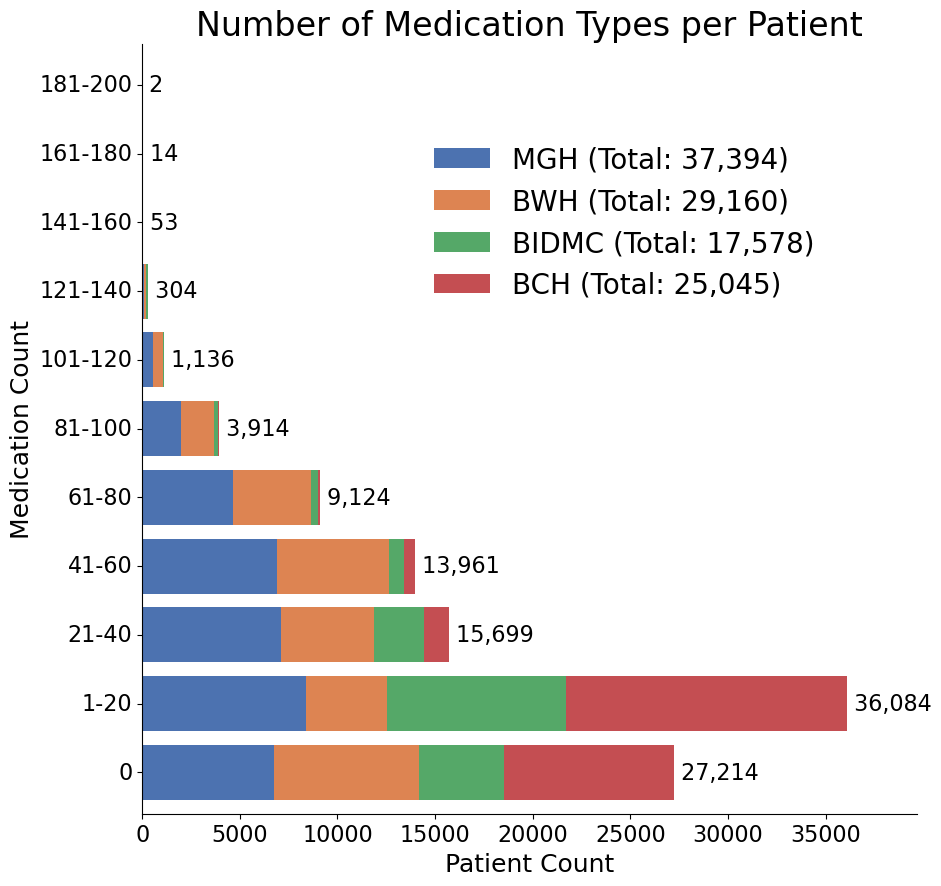

图表已保存到: /Users/chenxisun/Downloads/HEEDB//heedb/MedicationTypeCount_distribution_horizontal.png


In [190]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = df_all[['BDSPPatientID','SiteID']]
medication_df = df.merge(medication_df, on=['BDSPPatientID','SiteID'], how='left')

files = ['S0001', 'S0002', 'I0002', 'I0003']
file_name = ['MGH', 'BWH', 'BIDMC', 'BCH']

out_dir = '/Users/chenxisun/Downloads/HEEDB//heedb'
os.makedirs(out_dir, exist_ok=True)

sns.set_palette("deep")

bins = [0, 1, 21, 41, 61, 81, 101, 121, 141, 161, 181, 201]
bin_labels = [
    '0', '1-20', '21-40', '41-60', '61-80', '81-100',
    '101-120', '121-140', '141-160', '161-180', '181-200'
]

bar_positions = np.arange(len(bin_labels)) + 0.5

combined_df = pd.DataFrame()
medication_counts_list = []
total_counts = []

for i, file in enumerate(files):
    df = medication_df[(medication_df['SiteID'] == file)]
    medication_counts = df['total'].astype(float)
    medication_groups = pd.cut(medication_counts, bins=bins, labels=bin_labels, right=False)
    medication_group_counts = medication_groups.value_counts().sort_index()
    medication_counts_list.append(medication_group_counts)
    total_counts.append(len(df))
    combined_df = pd.concat([combined_df, df])

combined_medication_counts = combined_df['total'].astype(float)
combined_medication_groups = pd.cut(combined_medication_counts, bins=bins, labels=bin_labels, right=False)
combined_medication_group_counts = combined_medication_groups.value_counts().sort_index()

plt.figure(figsize=(10, 10))

left = np.zeros(len(bar_positions))
bars = []

for i, medication_counts in enumerate(medication_counts_list):
    bar = plt.barh(
        bar_positions, medication_counts.values, height=0.8, left=left,
        color=sns.color_palette()[i % len(sns.color_palette())], align='center'
    )
    bars.append(bar)
    left += medication_counts.values

for pos, total in zip(bar_positions, left):
    if total > 0:
        plt.text(total + 5, pos, f' {int(total):,}',
                 ha='left', va='center', fontsize=16, color='black')

plt.title('Number of Medication Types per Patient', fontsize=24)
plt.xlabel('Patient Count', fontsize=18)
plt.ylabel('Medication Count', fontsize=18)

plt.yticks(bar_positions, bin_labels, va='center', fontsize=16)
plt.xticks(fontsize=16)

plt.xlim(0, max(left) * 1.1)
plt.ylim(bottom=bar_positions[0] - 0.6, top=bar_positions[-1] + 0.6)

sns.despine()

legend_labels = [
    f"{file} (Total: {total_count:,})"
    for file, total_count in zip(file_name, total_counts)
]

plt.legend(
    [bar[0] for bar in bars], legend_labels,
    frameon=False, fontsize=20, loc='upper right', bbox_to_anchor=(0.9, 0.9)
)

output_file_path = os.path.join(out_dir, 'MedicationTypeCount_distribution_horizontal.png')
plt.savefig(output_file_path, dpi=500, bbox_inches='tight')
plt.show()
plt.close()

print(f"图表已保存到: {output_file_path}")